Если окружение ещё не настроено:

```python
# %pip install pandas pyarrow numpy matplotlib seaborn scikit-learn jupyter ipykernel
```


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl  

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [6]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

TRACK = "team"  # "solo" or "team"
TRAIN_DAYS = 14
MAX_TRAIN_ROWS = 1_500_000
RIDGE_ALPHA = 4.0
RANDOM_STATE = 42

DATA_PATH = '/Users/lubovklepcova/Desktop/Siriusly/ML/wb/Dd2WPGKz/'

TRACK_CONFIG = {
    "solo": {
        "train_path": DATA_PATH + "train_solo_track.parquet",
        "test_path": DATA_PATH + "test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": DATA_PATH + "train_team_track.parquet",  
        "test_path": DATA_PATH + "test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]
FORECAST_POINTS = CONFIG["forecast_points"]
FUTURE_TARGET_COLS = [f"target_step_{step}" for step in range(1, FORECAST_POINTS + 1)]


## Загрузка данных


In [7]:
train_df = pd.read_parquet(CONFIG["train_path"])
test_df = pd.read_parquet(CONFIG["test_path"])

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


track: team
train shape: (4342000, 12)
test shape: (10000, 3)


In [8]:
display(train_df.head())
display(test_df.head())


,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,26,0,2025-03-01 00:00:00,0,46,0,0,12,9,0,0,79.0
1,26,0,2025-03-01 00:30:00,0,34,0,0,16,0,187,0,88.0
2,26,0,2025-03-01 01:00:00,0,19,0,0,31,0,0,0,88.0
3,26,0,2025-03-01 01:30:00,0,33,0,0,36,129,0,0,88.0
4,26,0,2025-03-01 02:00:00,0,24,0,0,55,12,0,0,103.0


,id,route_id,timestamp
0,4900,0,2025-05-30 11:00:00
1,4901,0,2025-05-30 11:30:00
2,4902,0,2025-05-30 12:00:00
3,4903,0,2025-05-30 12:30:00
4,4904,0,2025-05-30 13:00:00


In [9]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())


Train date range: 2025-03-01 00:00:00 -> 2025-05-30 10:30:00
Test date range: 2025-05-30 11:00:00 -> 2025-05-30 15:30:00
Train routes: 1000
Test routes: 1000


## EDA train-данных


In [10]:
overview = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing_cnt": train_df.isna().sum(),
        "missing_pct": (train_df.isna().mean() * 100).round(4),
        "n_unique": train_df.nunique(dropna=False),
    }
)
overview


,dtype,missing_cnt,missing_pct,n_unique
office_from_id,int64,0,0.0,53
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,4342
status_1,int64,0,0.0,19752
status_2,int64,0,0.0,2127
status_3,int64,0,0.0,17998
status_4,int64,0,0.0,14416
status_5,int64,0,0.0,17108
status_6,int64,0,0.0,17616
status_7,int64,0,0.0,38219


In [11]:
status_cols = sorted([col for col in train_df.columns if col.startswith("status_")])
print("Status columns:", status_cols)
print("Target column:", TARGET_COL)
print("Forecast points:", FORECAST_POINTS)


Status columns: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']
Target column: target_2h
Forecast points: 10


## Распределения


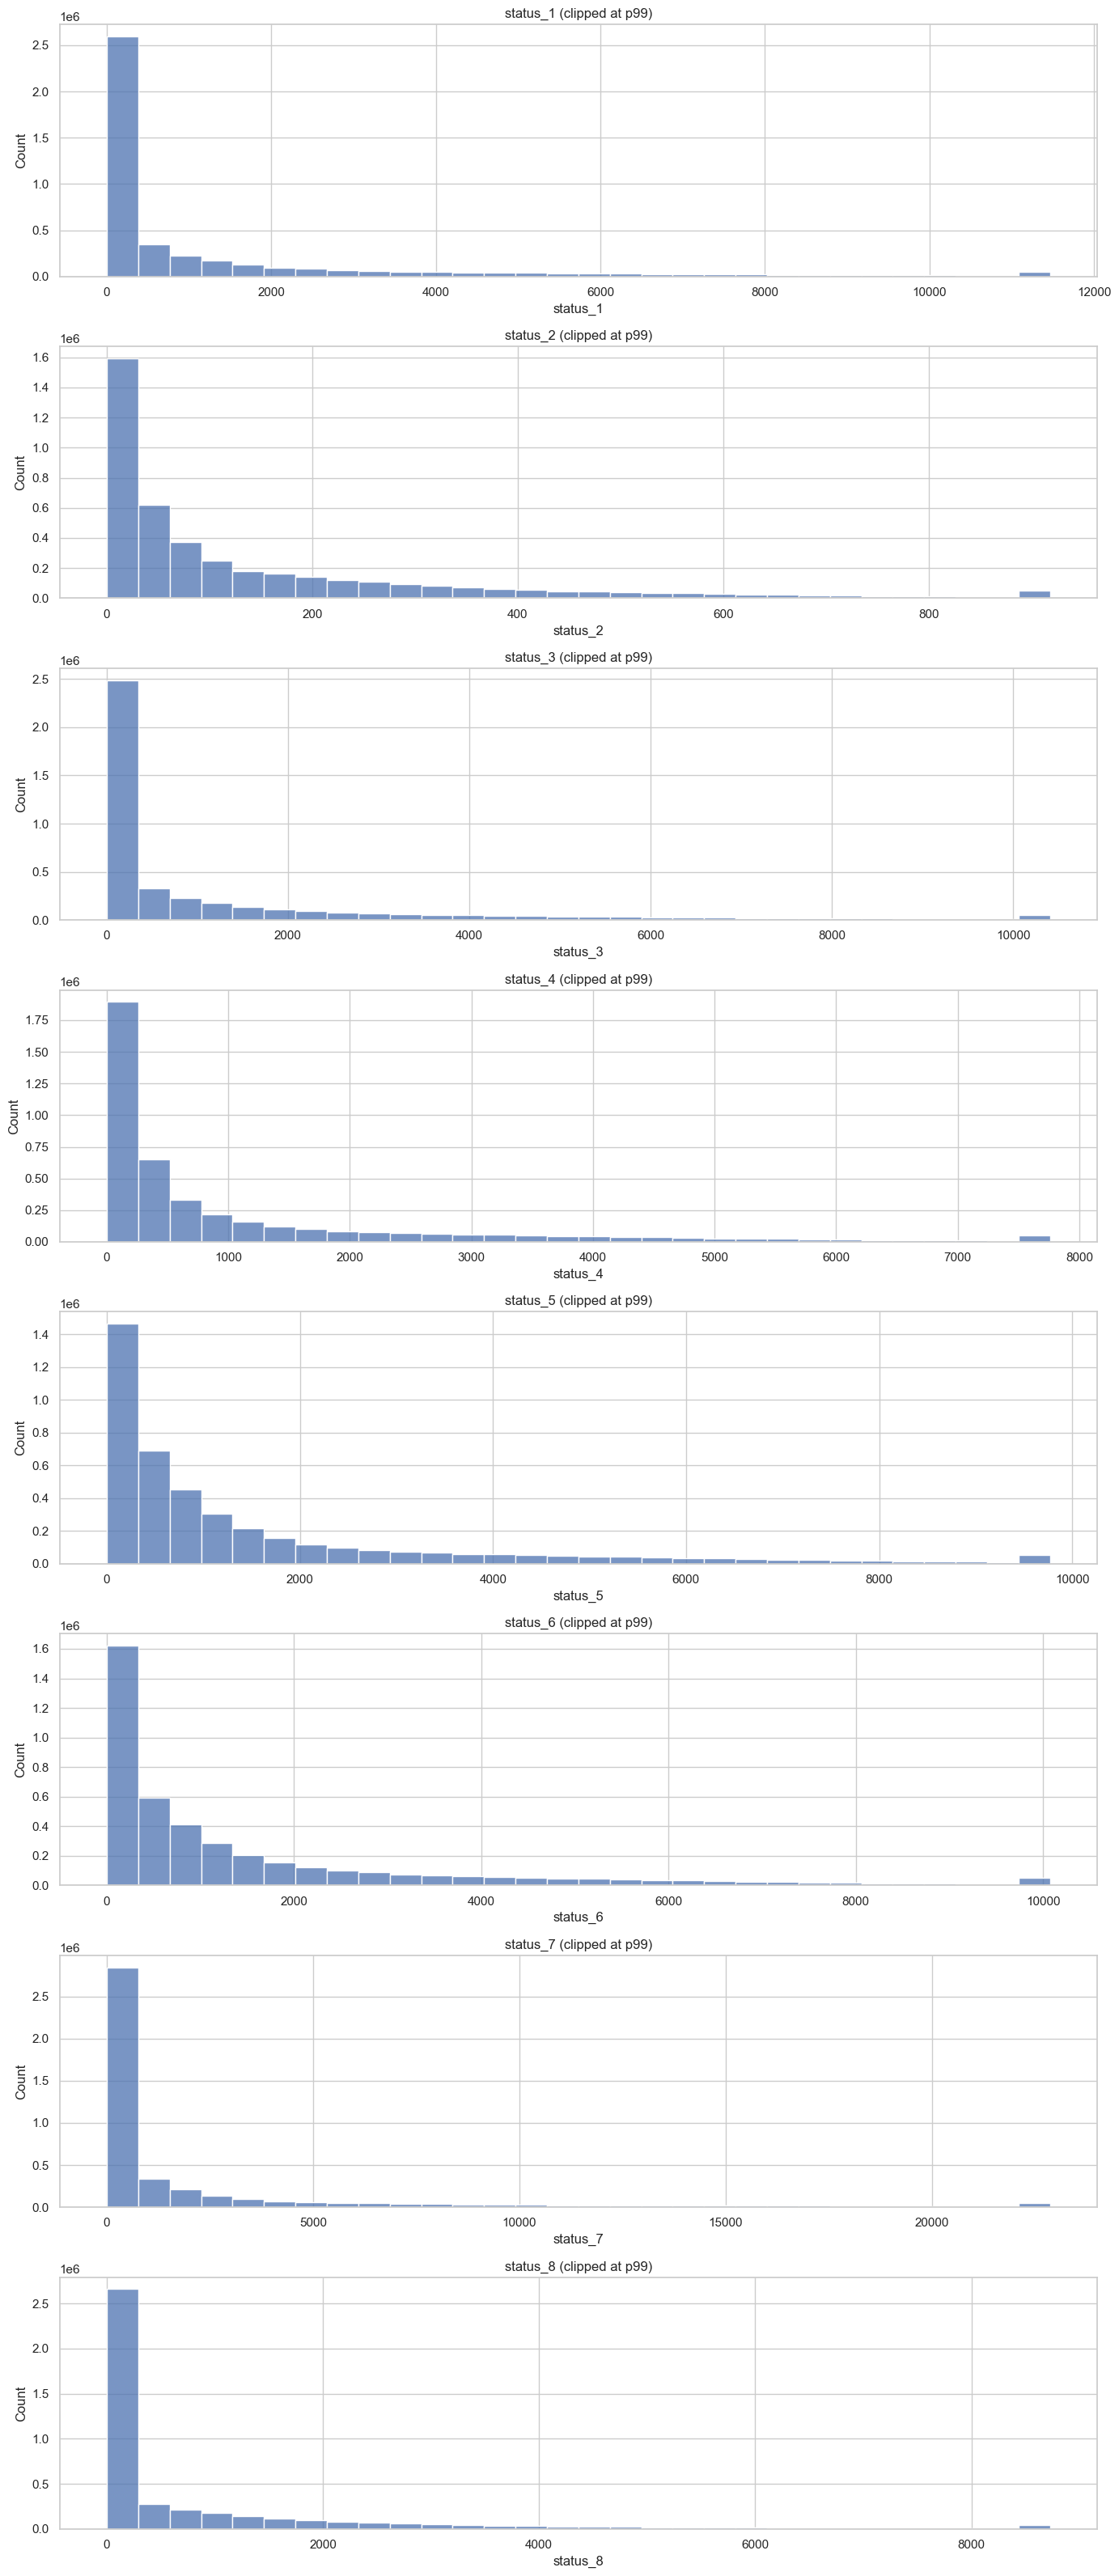

In [12]:
fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 4 * len(status_cols)))

if len(status_cols) == 1:
    axes = [axes]

for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")

plt.tight_layout()
plt.show()


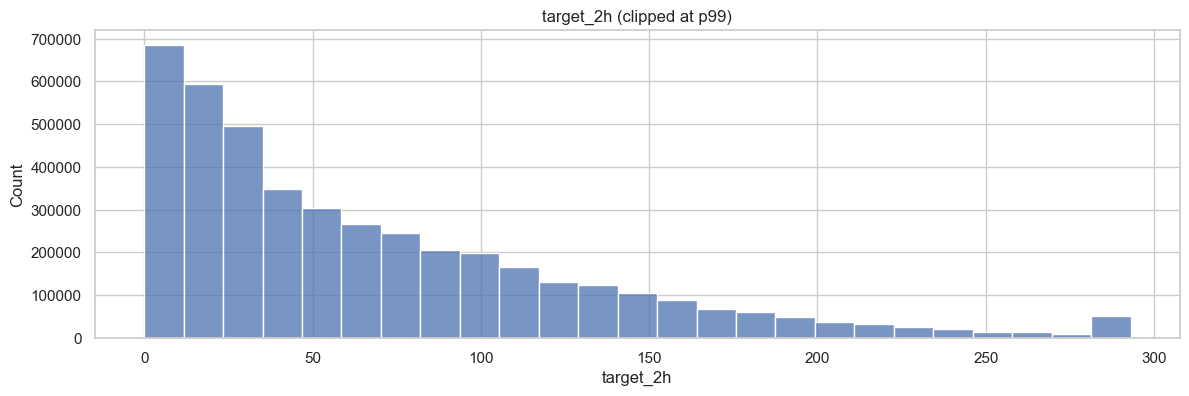

In [13]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df[TARGET_COL].clip(upper=train_df[TARGET_COL].quantile(0.99)), bins=25, kde=False)
plt.title(f"{TARGET_COL} (clipped at p99)")
plt.show()


## Генерируем будущие таргеты


In [14]:
route_group = train_df.groupby("route_id", sort=False)

for step in range(1, FORECAST_POINTS + 1):
    train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)

train_df[["route_id", "timestamp", TARGET_COL] + FUTURE_TARGET_COLS].head(10)


,route_id,timestamp,target_2h,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
0,0,2025-03-01 00:00:00,79.0,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0
1,0,2025-03-01 00:30:00,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0
2,0,2025-03-01 01:00:00,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0
3,0,2025-03-01 01:30:00,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0
4,0,2025-03-01 02:00:00,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0
5,0,2025-03-01 02:30:00,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0
6,0,2025-03-01 03:00:00,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0
7,0,2025-03-01 03:30:00,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0
8,0,2025-03-01 04:00:00,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0,92.0
9,0,2025-03-01 04:30:00,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0,92.0,92.0


In [15]:
supervised_df = train_df.dropna(subset=FUTURE_TARGET_COLS).copy()
print("Rows with future targets:", supervised_df.shape)


Rows with future targets: (4332000, 22)


## Корреляции


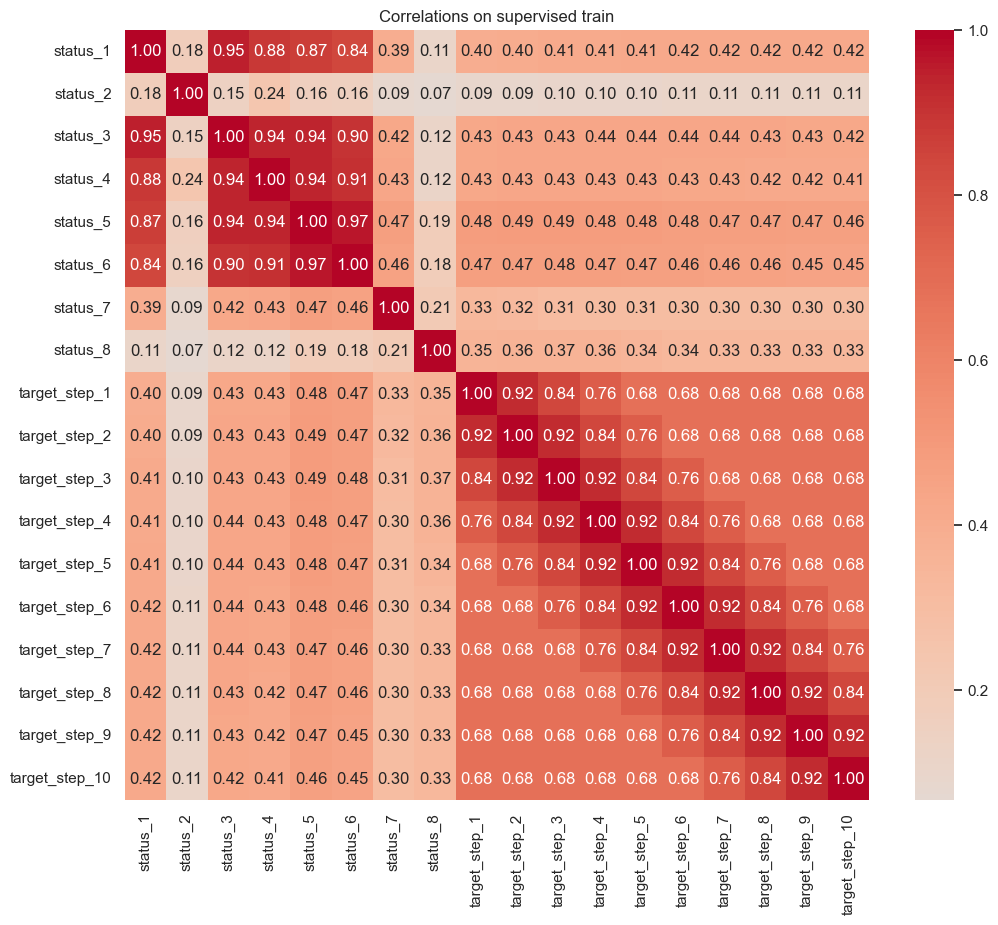

In [16]:
corr_cols = status_cols + FUTURE_TARGET_COLS
corr = supervised_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations on supervised train")
plt.show()


## Подготовка train и test


In [17]:
feature_cols = [col for col in train_df.columns if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}]

print("Feature columns:", feature_cols)


Feature columns: ['office_from_id', 'route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']


In [18]:
train_model_df = supervised_df[feature_cols + ["timestamp"] + FUTURE_TARGET_COLS].copy()
train_model_df = train_model_df.rename(columns={"timestamp": "source_timestamp"})

train_ts_max = train_model_df["source_timestamp"].max()
train_window_start = train_ts_max - pd.Timedelta(days=TRAIN_DAYS)
train_model_df = train_model_df[train_model_df["source_timestamp"] >= train_window_start].copy()

print("Recent train rows:", train_model_df.shape)


Recent train rows: (673000, 21)


In [19]:
# последний момент факта, из которого делаем прогноз
inference_ts = train_df["timestamp"].max()
test_model_df = train_df[train_df["timestamp"] == inference_ts]

print("Test rows:", test_model_df.shape)


Test rows: (1000, 22)


## Time-based split


In [20]:
train_model_df = train_model_df.sort_values("source_timestamp").copy()
split_point = train_model_df["source_timestamp"].quantile(0.8)

fit_df = train_model_df[train_model_df["source_timestamp"] <= split_point].copy()
valid_df = train_model_df[train_model_df["source_timestamp"] > split_point].copy()

if len(fit_df) > MAX_TRAIN_ROWS:
    fit_df = fit_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE)

print("Fit rows:", fit_df.shape)
print("Valid rows:", valid_df.shape)


Fit rows: (539000, 21)
Valid rows: (134000, 21)


In [21]:
X_fit = fit_df[feature_cols].copy()
y_fit = fit_df[FUTURE_TARGET_COLS].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[FUTURE_TARGET_COLS].copy()

X_test = test_model_df[feature_cols].copy()


## Линейный baseline


In [22]:
categorical_features = [col for col in feature_cols if col.endswith("_id")]
numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['office_from_id', 'route_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=RIDGE_ALPHA)),
    ]
)


In [24]:
model.fit(X_fit, y_fit)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [25]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=fit_df.index)
valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=valid_df.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

valid_pred_df.head()


,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
3634110,22.473376,22.561388,22.630536,22.393254,22.132838,21.937824,21.823976,21.747290,21.649822,21.555717
807468,62.033640,62.067304,61.896550,60.782460,59.517588,58.931586,58.365547,57.679028,57.144109,56.786919
2066648,10.778782,10.554479,10.345470,10.109569,10.125949,10.279596,10.332071,10.323866,10.380989,10.404528
1276404,32.175245,31.721706,31.315746,30.747026,30.767022,30.971129,31.030069,31.130449,31.012003,30.842640
1840864,107.782033,108.626124,107.241150,105.826938,103.345309,102.787398,103.300088,104.353376,104.948797,105.591351


## Метрики


In [26]:
class WapePlusRbias:
    """Calculates as WAPE + Relative Bias."""

    @property
    def name(self) -> str:
        """Возвращает имя метрики."""
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Рассчитывает значение метрики."""
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias


metric = WapePlusRbias()

In [27]:
print('Метрики на тесте (по горизонтам):')
display(np.round(metric.calculate(y_fit, fit_pred_df), 2))

print('Общая метрика на тесте:')
print(f'{metric.calculate(y_fit.to_numpy().flatten(), fit_pred_df.to_numpy().flatten()):.2f}')

Метрики на тесте (по горизонтам):


target_step_1     0.29
target_step_2     0.29
target_step_3     0.29
target_step_4     0.29
target_step_5     0.29
target_step_6     0.30
target_step_7     0.30
target_step_8     0.30
target_step_9     0.30
target_step_10    0.30
dtype: float64

Общая метрика на тесте:
0.29


In [28]:
print('Метрики на валидации (по горизонтам):')
display(np.round(metric.calculate(y_valid, valid_pred_df), 2))

print('Общая метрика на валидации:')
print(f'{metric.calculate(y_valid.to_numpy().flatten(), valid_pred_df.to_numpy().flatten()):.2f}')

Метрики на валидации (по горизонтам):


target_step_1     0.31
target_step_2     0.31
target_step_3     0.31
target_step_4     0.31
target_step_5     0.32
target_step_6     0.32
target_step_7     0.33
target_step_8     0.33
target_step_9     0.34
target_step_10    0.34
dtype: float64

Общая метрика на валидации:
0.32


## Конвертируем прогноз в нужный формат 


In [29]:
# добавляем к прогнозу маршруты
test_pred_df['route_id'] = X_test['route_id']

# разворачиваем target_step_* в строки
forecast_df = test_pred_df.melt(
    id_vars="route_id",
    value_vars=[c for c in test_pred_df.columns if c.startswith("target_step_")],
    var_name="step",
    value_name="forecast"
)

# достаем номер шага из target_step_1, target_step_2, ...
forecast_df["step_num"] = forecast_df["step"].str.extract(r"(\d+)").astype(int)

# строим timestamp: каждый шаг = +30 минут от времени прогноза
forecast_df["timestamp"] = inference_ts + pd.to_timedelta(forecast_df["step_num"] * 30, unit="m")

# оставляем нужные столбцы
forecast_df = forecast_df[["route_id", "timestamp", "forecast"]].sort_values(
    ["route_id", "timestamp"]
).reset_index(drop=True)

forecast_df = test_df.merge(forecast_df, 'outer')[["id", "forecast"]]
forecast_df = forecast_df.rename(columns={"forecast": "y_pred"})

In [30]:
forecast_df.head()

,id,y_pred
0,4900,20.731973
1,4901,20.759722
2,4902,20.652299
3,4903,20.680028
4,4904,20.641718


In [31]:
# проверяем, что все точки получены
assert forecast_df['id'].isna().sum() == 0


## Выгрузка CSV


In [32]:
submission_path =  f"submission_{TRACK}.csv"
joined_path =  f"test_with_forecast_{TRACK}.csv"

forecast_df.to_csv(submission_path, index=False)

print("submission saved to:", submission_path)

submission saved to: submission_team.csv
